In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import cmasher as cmr
%matplotlib widget

pa.settings.strict_units = False

# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([500., 500., 500.], dtype=float)


# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
# filter_length = 2*snap['0_Diameters']



The default number of OpenMP threads, 8, exceeds the 1 available on your system. Setting numthreads=1. You can set numthreads with e.g. the command
 paicos.set_numthreads(16)




In [2]:
numPoints = 256

In [3]:
depo_NGP = tc.DepositCartesianGrid(snap, center, widths, npoints=numPoints, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type='NGP')

Attempting to get derived variable: 0_Volume...	[DONE]



In [4]:
depo_CIC = tc.DepositCartesianGrid(snap, center, widths, npoints=numPoints, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type='CIC')

In [5]:
depo_TSC = tc.DepositCartesianGrid(snap, center, widths, npoints=numPoints, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="TSC")

In [6]:
depo_PCS = tc.DepositCartesianGrid(snap, center, widths, npoints=numPoints, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="PCS")

In [7]:
depo_CIC.Np

3585497

In [8]:
density_cartesian_NGP = depo_NGP.deposit_variable('0_Density', weight='0_Volume')

In [9]:
density_cartesian_CIC = depo_CIC.deposit_variable('0_Density', weight='0_Volume')

In [10]:
density_cartesian_TSC = depo_TSC.deposit_variable('0_Density', weight='0_Volume')

In [11]:
density_cartesian_PCS = depo_PCS.deposit_variable('0_Density', weight='0_Volume')

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=numPoints)
extent = slicer.centered_extent.to('Mpc')

Text(0.5, 0.95, 'Density field (voronoi and cartesian)')

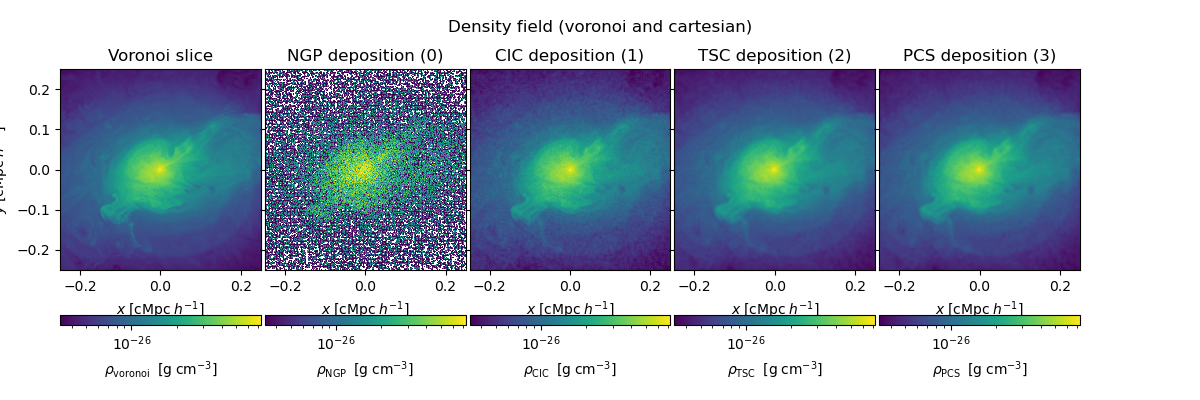

In [13]:


dens_voro = slicer.slice_variable('0_Density')
""" 
I am not sure why here I need to transpose to make sure
the alignment is the same as the slice
""" 
dens_cart_NGP = (density_cartesian_NGP[:,:,int(depo_NGP.npoints[2]//2)-1].T).to_physical.cgs
dens_cart_CIC = (density_cartesian_CIC[:,:,int(depo_NGP.npoints[2]//2)-1].T).to_physical.cgs
dens_cart_TSC = (density_cartesian_TSC[:,:,int(depo_NGP.npoints[2]//2)-1].T).to_physical.cgs
dens_cart_PCS = (density_cartesian_PCS[:,:,int(depo_NGP.npoints[2]//2)-1].T).to_physical.cgs
# dens_bulk = slicer.slice_variable(smoothVar)
# dens_turb = slicer.slice_variable(relativeTurbVar)

dens_voro = dens_voro.to_physical.cgs

vmin = np.min(dens_voro.value)
vmax = np.max(dens_voro.value)
norm = LogNorm(vmin=vmin,vmax=vmax)

cmap = cmr.fusion

fig, axes = plt.subplots(1,5, figsize=(12,4),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_voro.value, origin='lower', norm=norm,extent=extent.value)

im2 = axes[1].imshow(
    dens_cart_NGP.value, origin='lower', norm=norm,extent=extent.value)

im3 = axes[2].imshow(
    dens_cart_CIC.value, origin='lower', norm=norm,extent=extent.value)

im4 = axes[3].imshow(
    dens_cart_TSC.value, origin='lower', norm=norm,extent=extent.value)

im5 = axes[4].imshow(
    dens_cart_PCS.value, origin='lower', norm=norm,extent=extent.value)


axes[0].set_title('Voronoi slice')
axes[1].set_title('NGP deposition (0)')
axes[2].set_title('CIC deposition (1)')
axes[3].set_title('TSC deposition (2)')
axes[4].set_title('PCS deposition (3)')


for i in range(5):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_voro.label('\\rho_{\mathrm{voronoi}}'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_cart_NGP.label('\\rho_{\mathrm{NGP}}'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(dens_cart_CIC.label('\\rho_{\mathrm{CIC}}'))

cbar = fig.colorbar(im4, orientation='horizontal')
cbar.set_label(dens_cart_TSC.label('\\rho_{\mathrm{TSC}}'))

cbar = fig.colorbar(im5, orientation='horizontal')
cbar.set_label(dens_cart_PCS.label('\\rho_{\mathrm{PCS}}'))


fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.05,
right=0.90,
hspace=0.0,
wspace=0.02)

fig.suptitle('Density field (voronoi and cartesian)',y=0.95)
# plt.savefig('deposit_comparison.pdf',dpi=400)
# plt.close()

## Test on a smaller sub-region

### This is in order to check that the mass is exactly conserved. I select a smaller
region and zero-out the surroundings, so that even with different interpolations
the amount of mass contained in the smaller region does not change. Here the number of empty cells 
is not meaningful because it includes those zeroed-out.

In [14]:
depo_small = tc.DepositCartesianGrid(snap, center, widths/4,npoints=numPoints, 
                                     threadsperblock=256, regionType='cartesian')

In [15]:
voxel = float(depo_NGP.tile_widths[0]*depo_NGP.tile_widths[1]*depo_NGP.tile_widths[2])*snap['0_Volume'].unit

In [16]:
density_masked = np.zeros_like(snap['0_Density'])

In [17]:
density_masked[depo_small.index] = snap['0_Density'][depo_small.index]

In [18]:
np.min(snap['0_Coordinates'][depo_small.index][:,0]-center[0])

<PaicosQuantity -70.18732214 arepo_length small_a / small_h>

In [19]:
depo_small.widths

<PaicosQuantity [125., 125., 125.] arepo_length small_a / small_h>

In [20]:
tot_mass_small = np.sum(density_masked * snap['0_Volume'])
print(tot_mass_small)

213.18056465609698 arepo_mass / small_h


In [21]:
new_depo_NGP = tc.DepositCartesianGrid(snap, center, widths, npoints=numPoints, threadsperblock=256, 
               regionType='cartesian', kernel_type="NGP")
density_cartesian_small_NGP = new_depo_NGP.deposit_variable(density_masked, 
                                                          weight='0_Volume')

In [22]:
np.sum(density_cartesian_small_NGP * voxel)

<PaicosQuantity 213.18056466 arepo_mass / small_h>

In [23]:
new_depo_CIC = tc.DepositCartesianGrid(snap, center, widths, npoints=numPoints, 
                                       threadsperblock=256, 
                                       regionType='cartesian', kernel_type="CIC")
density_cartesian_small_CIC = new_depo_CIC.deposit_variable(density_masked, 
                                                          weight='0_Volume')

In [24]:
np.sum(density_cartesian_small_CIC * voxel)

<PaicosQuantity 213.18056466 arepo_mass / small_h>

In [25]:
new_depo_TSC = tc.DepositCartesianGrid(snap, center, widths, npoints=numPoints, 
                                       threadsperblock=256, 
                                       regionType='cartesian', kernel_type="TSC")
density_cartesian_small_TSC = new_depo_TSC.deposit_variable(density_masked, 
                                                    weight='0_Volume')

In [26]:
np.sum(density_cartesian_small_TSC * voxel)

<PaicosQuantity 213.18056466 arepo_mass / small_h>

In [27]:
new_depo_PCS = tc.DepositCartesianGrid(snap, center, widths, npoints=numPoints, 
                                       threadsperblock=256, 
                                       regionType='cartesian', kernel_type="PCS")
density_cartesian_small_PCS = new_depo_PCS.deposit_variable(density_masked, 
                                                    weight='0_Volume')

In [28]:
np.sum(density_cartesian_small_PCS * voxel)

<PaicosQuantity 213.18056466 arepo_mass / small_h>

Text(0.5, 0.95, 'Density field smaller region (voronoi and cartesian)')

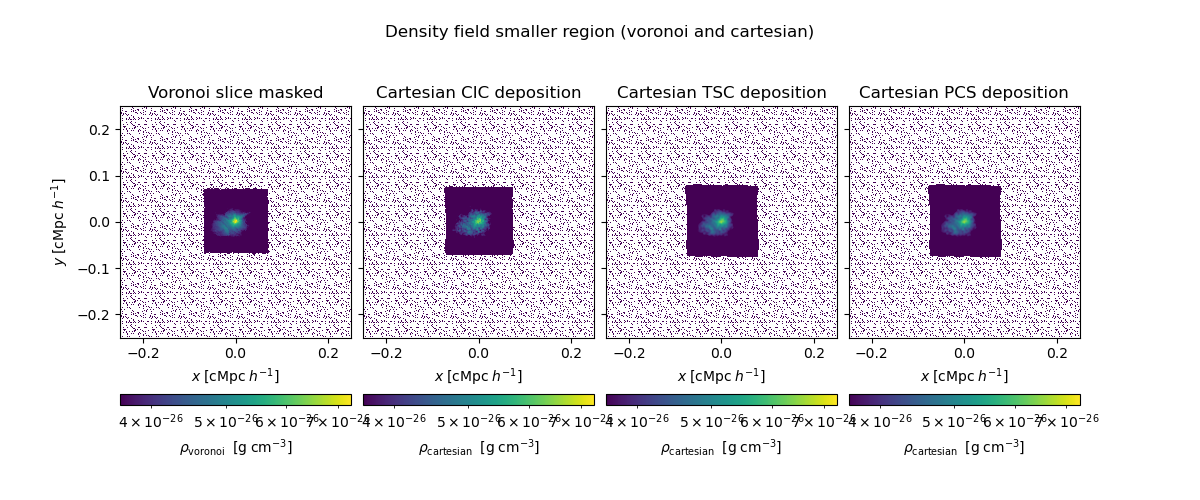

In [29]:
## This is just to check graphically the subregion

dens_voro = slicer.slice_variable(density_masked)
""" 
I am not sure why here I need to transpose to make sure
the alignment is the same as the slice
""" 
dens_cart_cic = density_cartesian_small_CIC[:,:,int(depo_NGP.npixs[2]//2)-1].T
dens_cart_tsc = density_cartesian_small_TSC[:,:,int(depo_NGP.npixs[2]//2)-1].T
dens_cart_pcs = density_cartesian_small_PCS[:,:,int(depo_NGP.npixs[2]//2)-1].T
# dens_bulk = slicer.slice_variable(smoothVar)
# dens_turb = slicer.slice_variable(relativeTurbVar)
# delta_density_rel = (dens_voro - dens_cart) / dens_voro

dens_voro = dens_voro.to_physical.cgs
dens_cart_cic = dens_cart_cic.to_physical.cgs
dens_cart_tsc = dens_cart_tsc.to_physical.cgs
dens_cart_pcs = dens_cart_pcs.to_physical.cgs
# dens_turb = dens_turb.to_physical.cgs

vmin = 0.5*np.max(dens_voro.value)
vmax = np.max(dens_voro.value)
norm = LogNorm(vmin=vmin,vmax=vmax)


# vmin = -0.8*delta_density_rel.max()
# vmax = 0.8*delta_density_rel.max()
# print(vmin)
# norm1 = Normalize(vmin=vmin,vmax=vmax)
cmap = cmr.fusion

fig, axes = plt.subplots(1,4, figsize=(12,5),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_voro.value, origin='lower', norm=norm,extent=extent.value)

im2 = axes[1].imshow(
    dens_cart_cic.value, origin='lower', norm=norm,extent=extent.value)

im3 = axes[2].imshow(
    dens_cart_tsc.value, origin='lower', norm=norm, extent=extent.value)

im4 = axes[3].imshow(
    dens_cart_pcs.value, origin='lower', norm=norm, extent=extent.value)

axes[0].set_title('Voronoi slice masked')
axes[1].set_title('Cartesian CIC deposition')
axes[2].set_title('Cartesian TSC deposition')
axes[3].set_title('Cartesian PCS deposition')

for i in range(4):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_voro.label('\\rho_{\mathrm{voronoi}}'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_cart_cic.label('\\rho_{\mathrm{cartesian}}'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(dens_cart_tsc.label('\\rho_{\mathrm{cartesian}}'))

cbar = fig.colorbar(im4, orientation='horizontal')
cbar.set_label(dens_cart_pcs.label('\\rho_{\mathrm{cartesian}}'))


fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field smaller region (voronoi and cartesian)',y=0.95)
# plt.savefig(f'Halo{halo}_density_center_non_starforming.pdf')
# plt.close()